1. Wczytanie danych
2. Przygotowanie danych
Liczba usuniętych wierszy: 342
3. Trenowanie modelu Random Forest
4. Predykcja na zbiorze testowym
5. Ocena modelu
Confusion Matrix:
[[91283     0]
 [   16   427]]


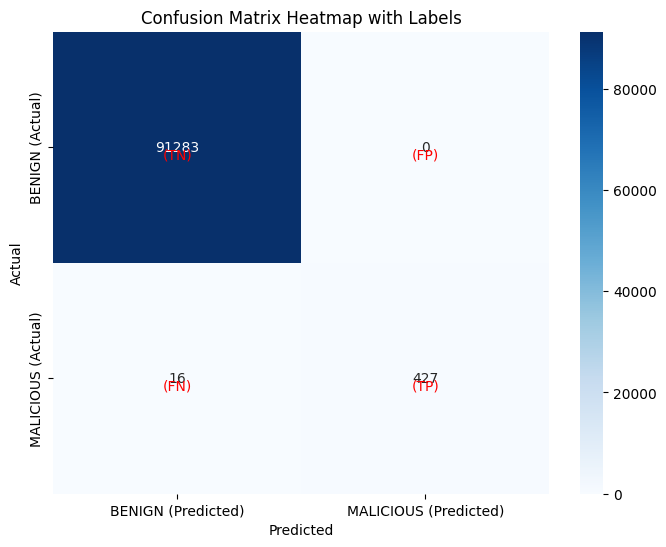

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     91283
   MALICIOUS       1.00      0.96      0.98       443

    accuracy                           1.00     91726
   macro avg       1.00      0.98      0.99     91726
weighted avg       1.00      1.00      1.00     91726

6. Opcjonalnie: Ważność cech
Feature Importances:
Feature 0: 0.0439
Feature 1: 0.0201
Feature 2: 0.0087
Feature 3: 0.0012
Feature 4: 0.0399
Feature 5: 0.0017
Feature 6: 0.0279
Feature 7: 0.0054
Feature 8: 0.0756
Feature 9: 0.0086
Feature 10: 0.0021
Feature 11: 0.0007
Feature 12: 0.0023
Feature 13: 0.0032
Feature 14: 0.0212
Feature 15: 0.0292
Feature 16: 0.0232
Feature 17: 0.0144
Feature 18: 0.0252
Feature 19: 0.0059
Feature 20: 0.0119
Feature 21: 0.0083
Feature 22: 0.0268
Feature 23: 0.0261
Feature 24: 0.0539
Feature 25: 0.0038
Feature 26: 0.0022
Feature 27: 0.0031
Feature 28: 0.0041
Feature 29: 0.0032
Feature 30: 0.0005
Feature 31: 0.0000
Fe

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


data = pd.read_csv('Thursday.csv')
df = data.copy()

rows_before = df.shape[0]

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

rows_after = df.shape[0]

rows_dropped = rows_before - rows_after
print(f"Liczba usuniętych wierszy: {rows_dropped}")
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

y = [0 if label == 'BENIGN' else 1 for label in y]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['BENIGN (Predicted)', 'MALICIOUS (Predicted)'], 
                 yticklabels=['BENIGN (Actual)', 'MALICIOUS (Actual)'])

labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.5, f'\n({labels[i][j]})', color='red', ha='center', va='center', fontsize=10)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap with Labels')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'MALICIOUS']))

feature_importances = rf_model.feature_importances_
print("Feature Importances:")
for i, importance in enumerate(feature_importances):
    print(f"Feature {i}: {importance:.4f}")

True Negatives (TN): 91,283 — poprawnie sklasyfikowane BENIGN.  
False Positives (FP): 0 — brak błędnych klasyfikacji BENIGN jako MALICIOUS.  
False Negatives (FN): 16 — MALICIOUS błędnie sklasyfikowane jako BENIGN.  
True Positives (TP): 427 — poprawnie wykryte MALICIOUS.  